In [28]:
!pip install ruptures
!pip install pyts
!pip install dynetx

<ipython-input-30-e3e1bc23508c>:8: DtypeWarning: Columns (97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/4_year_second_column.csv")


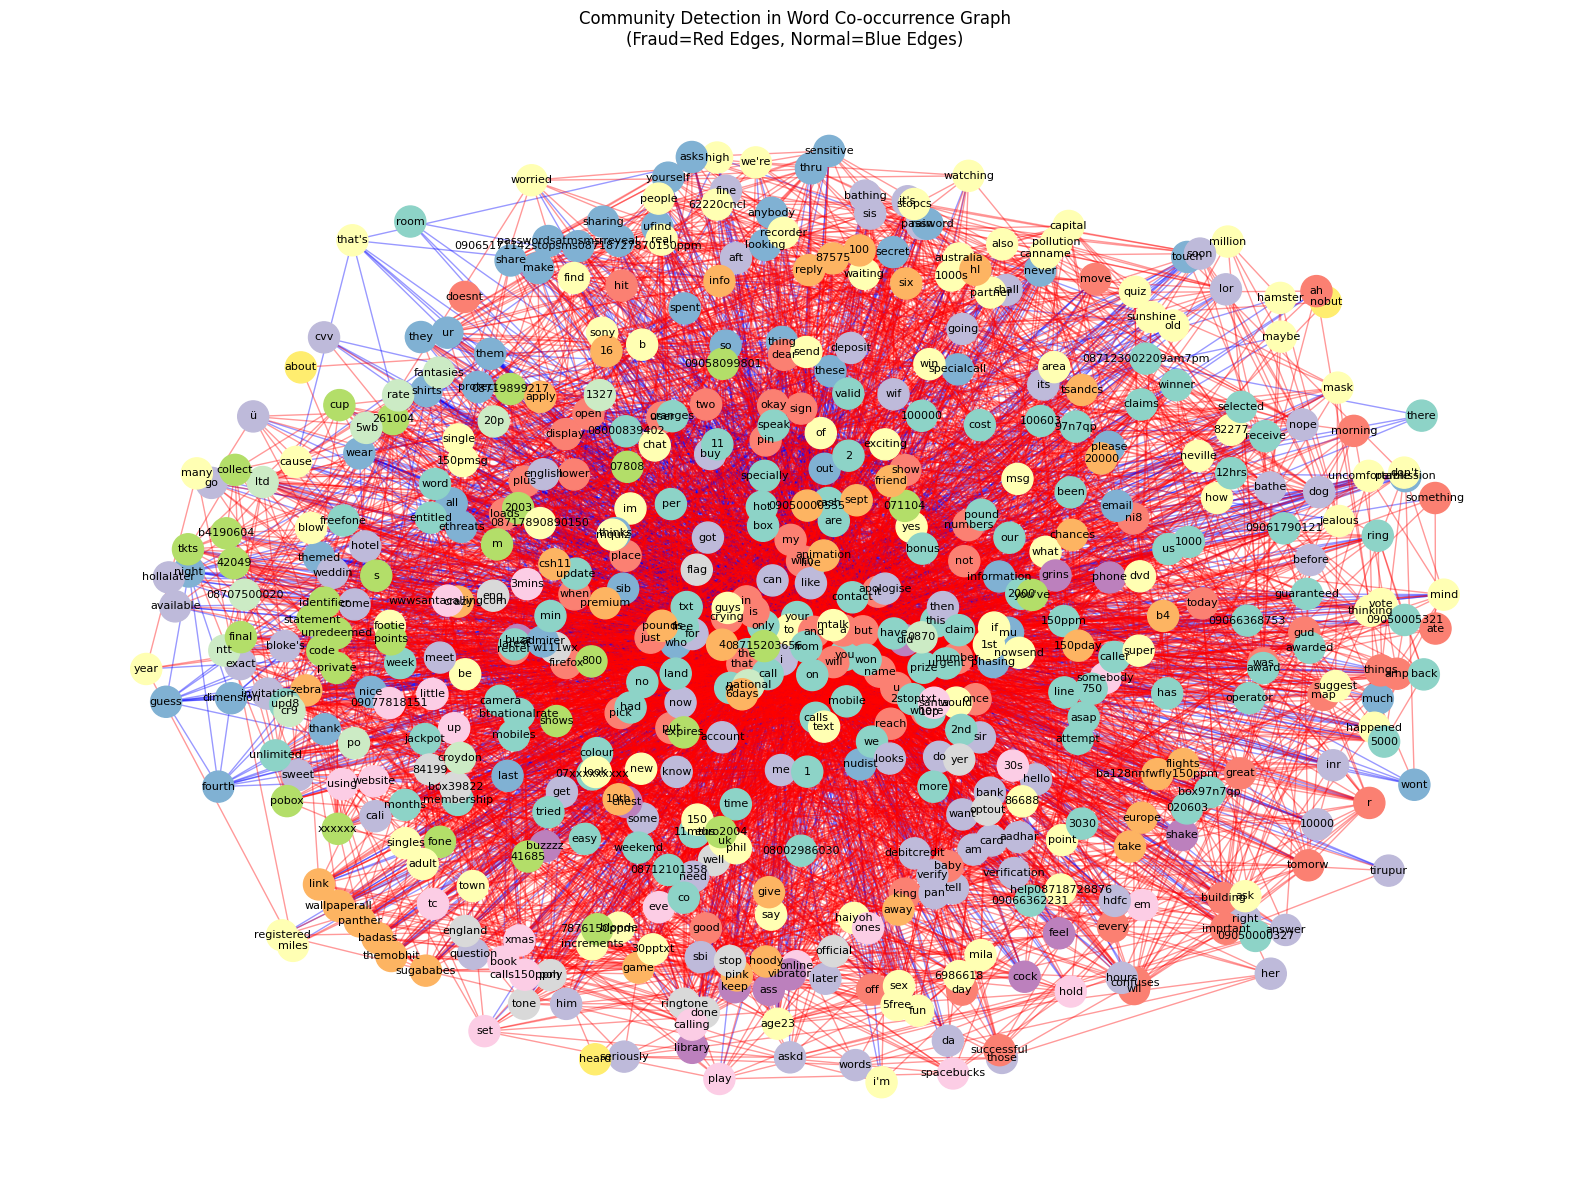

In [30]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from networkx.algorithms import community

# Load the dataset
df = pd.read_csv("/content/4_year_second_column.csv")

# Sample 30 normal and 30 fraud rows for clarity and balance
normal_df = df[df['label'].str.lower() == 'normal'].sample(n=30, random_state=42)
fraud_df = df[df['label'].str.lower() == 'fraud'].sample(n=30, random_state=42)
sample_df = pd.concat([normal_df, fraud_df])

# Create a graph
G = nx.Graph()
edge_colors = []

# Process each row to add edges
for _, row in sample_df.iterrows():
    label = row['label']
    words = [str(word).strip().lower()
             for word in row[2:].dropna()
             if pd.notna(word) and str(word).strip().lower() != 'nan']

    words = list(set(words))  # Remove duplicates
    for u, v in combinations(words, 2):
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)
        edge_colors.append("red" if label.lower() == "fraud" else "blue")

# Perform community detection using greedy modularity
communities = community.greedy_modularity_communities(G)

# Assign a color to each community
community_colors = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_colors[node] = i

# Assign node colors based on community
node_colors = [community_colors.get(node, 0) for node in G.nodes()]

# Draw the graph
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k = 0.8)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Set3, node_size=500)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Community Detection in Word Co-occurrence Graph\n(Fraud=Red Edges, Normal=Blue Edges)")
plt.axis('off')
plt.tight_layout()
plt.show()


<ipython-input-33-2b4f8d50ac1b>:8: DtypeWarning: Columns (97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/4_year_second_column.csv')
<ipython-input-33-2b4f8d50ac1b>:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10', len(communities))


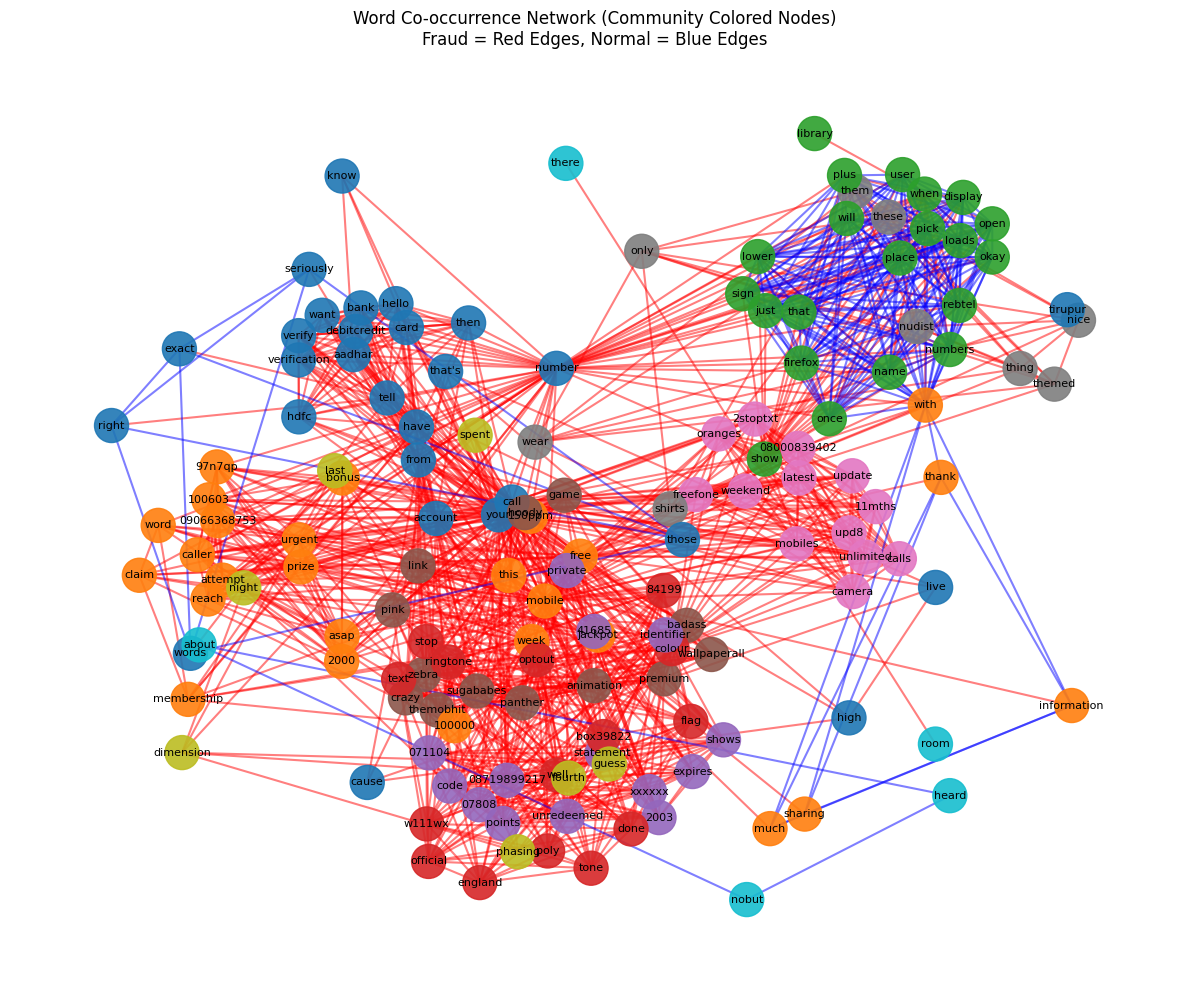

In [33]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from networkx.algorithms.community import greedy_modularity_communities

# Load dataset
df = pd.read_csv('/content/4_year_second_column.csv')

# Sample 10 fraud and 10 normal entries
sampled_df = pd.concat([
    df[df['label'].str.lower() == 'fraud'].sample(10, random_state=42),
    df[df['label'].str.lower() == 'normal'].sample(10, random_state=42)
])

# Build co-occurrence graph
G = nx.Graph()
edge_colors = []

for _, row in sampled_df.iterrows():
    label = row['label']
    words = [str(word).strip().lower() for word in row[2:].dropna()
             if isinstance(word, str) and len(word.strip()) > 3]
    words = list(set(words))  # remove duplicates in same row

    for u, v in combinations(words, 2):
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)

        edge_colors.append("red" if label.lower() == "fraud" else "blue")

# Community detection using greedy modularity
communities = list(greedy_modularity_communities(G))

# Assign community colors
node_colors = {}
palette = plt.cm.get_cmap('tab10', len(communities))
for i, community in enumerate(communities):
    for node in community:
        node_colors[node] = palette(i)

# Plot the graph
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.8)

nx.draw_networkx_nodes(G, pos,
                       node_color=[node_colors[n] for n in G.nodes()],
                       node_size=600, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=1.5, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

plt.title("Word Co-occurrence Network (Community Colored Nodes)\nFraud = Red Edges, Normal = Blue Edges")
plt.axis('off')
plt.tight_layout()
plt.show()


<ipython-input-34-9b311258f6e7>:8: DtypeWarning: Columns (97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/4_year_second_column.csv')
<ipython-input-34-9b311258f6e7>:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10', len(communities))


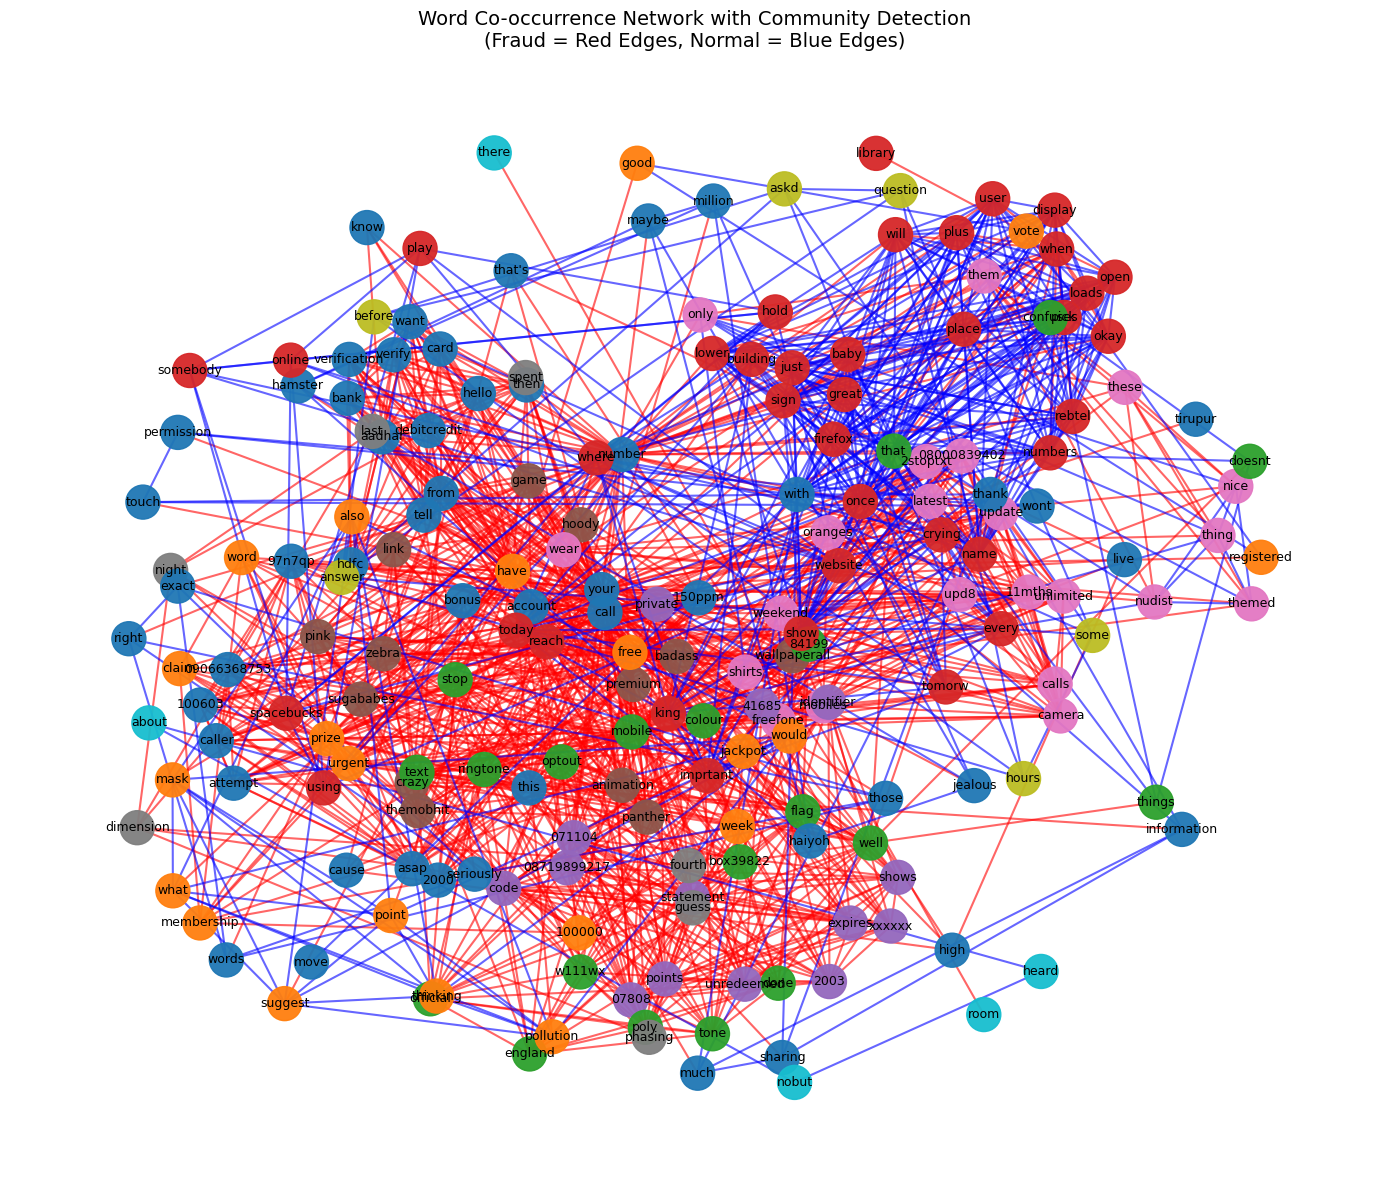

In [34]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from networkx.algorithms.community import greedy_modularity_communities

# Load dataset
df = pd.read_csv('/content/4_year_second_column.csv')

# Sample 10 fraud and 10 normal entries
sampled_df = pd.concat([
    df[df['label'].str.lower() == 'fraud'].sample(10, random_state=42),
    df[df['label'].str.lower() == 'normal'].sample(20, random_state=42)
])

# Build co-occurrence graph
G = nx.Graph()
edge_colors = []

for _, row in sampled_df.iterrows():
    label = row['label']
    words = [str(word).strip().lower() for word in row[2:].dropna()
             if isinstance(word, str) and len(word.strip()) > 3]
    words = list(set(words))  # remove duplicates in same row

    for u, v in combinations(words, 2):
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)

        edge_colors.append("red" if label.lower() == "fraud" else "blue")

# Community detection
communities = list(greedy_modularity_communities(G))

# Assign community colors
node_colors = {}
palette = plt.cm.get_cmap('tab10', len(communities))
for i, community in enumerate(communities):
    for node in community:
        node_colors[node] = palette(i)

# Increase node spacing using spring_layout with higher `k` value
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, seed=42, k=0.9)  # Increased from default (~0.5)

nx.draw_networkx_nodes(G, pos,
                       node_color=[node_colors[n] for n in G.nodes()],
                       node_size=600, alpha=0.95)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=1.5, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif')

plt.title("Word Co-occurrence Network with Community Detection\n(Fraud = Red Edges, Normal = Blue Edges)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()


Years available in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Plotting snapshot for year 2018


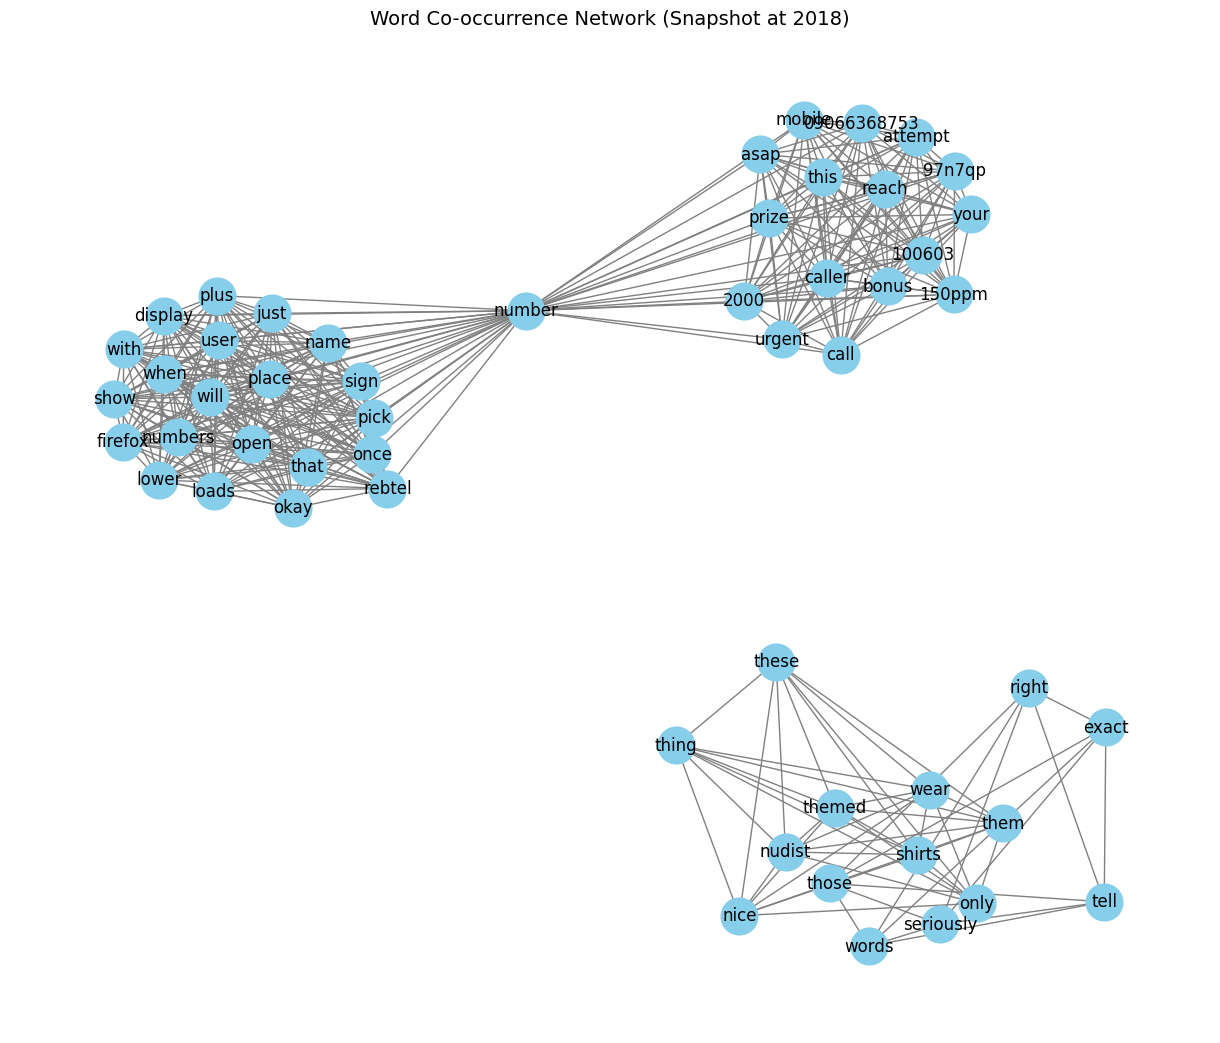

In [38]:
import pandas as pd
from dynetx import DynGraph
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Load the data
df = pd.read_csv('/content/4_year_second_column.csv', low_memory=False)

# Fix the 'year' column
# Convert to numeric and drop NaNs first
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])

# Now safely cast to integer
df['year'] = df['year'].astype(int)

#df['year'] = pd.to_numeric(df['year'], errors='coerce').astype(int)
df = df.dropna(subset=['year'])

# Display available years
print("Years available in dataset:", sorted(df['year'].unique()))

# Sample and sort by year to ensure increasing time order
sampled_df = pd.concat([
    df[df['label'].str.lower() == 'fraud'].sample(10, random_state=42),
    df[df['label'].str.lower() == 'normal'].sample(10, random_state=42)
]).sort_values(by='year')


# Create dynamic graph
DG = DynGraph()

# Add temporal interactions
for _, row in sampled_df.iterrows():
    year = int(row['year'])
    words = [str(word).strip().lower() for word in row[2:].dropna()
             if isinstance(word, str) and len(word.strip()) > 3]
    words = list(set(words))

    for u, v in combinations(words, 2):
        DG.add_interaction(u, v, t=year)

# Pick a valid year to visualize
year_to_plot = sampled_df['year'].mode().iloc[0]
print(f"Plotting snapshot for year {year_to_plot}")

# Draw the snapshot
if year_to_plot in DG.snapshots:
    snapshot = DG.time_slice(year_to_plot, year_to_plot + 1)

    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(snapshot, seed=42, k=0.8)
    nx.draw(snapshot, pos, with_labels=True, node_size=700, node_color='skyblue', edge_color='gray')
    plt.title(f"Word Co-occurrence Network (Snapshot at {year_to_plot})", fontsize=14)
    plt.axis('off')
    plt.show()
else:
    print(f"No interactions found for year {year_to_plot}")


In [39]:
# Collect network stats over time
years = sorted(DG.snapshots.keys())
edge_counts = []
for year in years:
    G = DG.time_slice(year, year + 1)
    edge_counts.append(G.number_of_edges())

# Create the time series
import numpy as np
ts = np.array(edge_counts)
print("Time series of edge counts:", ts)


Time series of edge counts: [136 121 138 137  47 437 418 214 197 133 132]


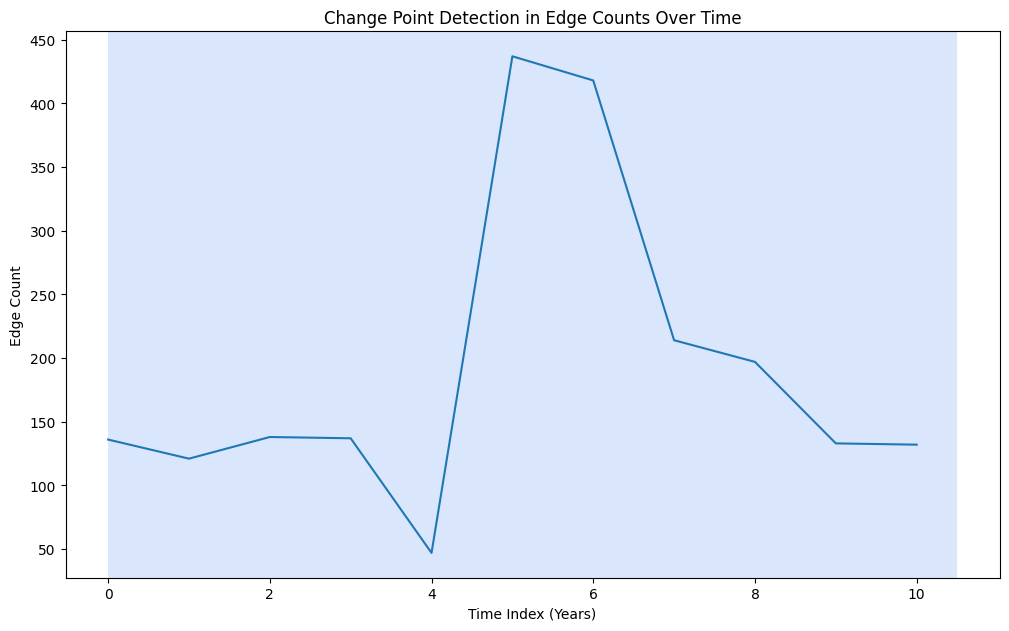

In [40]:

import ruptures as rpt

# Define and fit the model
model = rpt.Pelt(model="rbf").fit(ts)
change_points = model.predict(pen=3)

# Plot
rpt.display(ts, change_points, figsize=(10, 6))
plt.title("Change Point Detection in Edge Counts Over Time")
plt.xlabel("Time Index (Years)")
plt.ylabel("Edge Count")
plt.show()


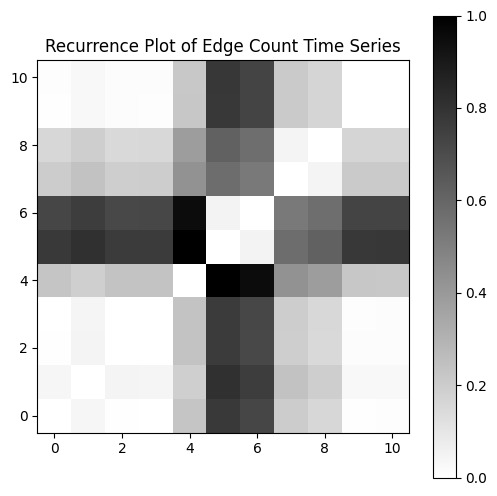

In [41]:
from pyts.image import RecurrencePlot
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts.reshape(-1, 1)).flatten()

# Generate recurrence plot
rp = RecurrencePlot()
X_rp = rp.fit_transform(ts_scaled.reshape(1, -1))

# Plot the recurrence plot
plt.figure(figsize=(6, 6))
plt.imshow(X_rp[0], cmap='binary', origin='lower')
plt.title("Recurrence Plot of Edge Count Time Series")
plt.colorbar()
plt.show()
